In [ ]:
# I hypothesized that we can improve the model in AAR1121v3.ipynb by incorporating information from the neighboring rooms.
# These are Rooms 1131, 1331, and 1315.
# This window downloads all relevant libraries and all data from the neighboring rooms.
# The code also sanitizes the room data and computes every sensible load.

import numpy as np
import pandas as pd
from src import df_sanitizer
import matplotlib.pyplot as plt
import seaborn
import datetime
import statsmodels

df1121 = pd.read_csv(r"Data/Rm1121 - VMA13.csv")
df1121 = df_sanitizer.sanitize_df(df1121)
df1121_sensible_load = 1.08 * df1121["supply air flow"] * (df1121["zone temp"] - df1121["supply air temp"])

df1131 = pd.read_csv(r"Data/Rm1131 - VMA12.csv")
df1131 = df_sanitizer.sanitize_df(df1131)
df1131_sensible_load = 1.08 * df1131["supply air flow"] * (df1131["zone temp"] - df1131["supply air temp"])

df1331 = pd.read_csv(r"Data/Rm1331 - VMA19.csv")
df1331 = df_sanitizer.sanitize_df(df1331)
df1331_sensible_load = 1.08 * df1331["supply air flow"] * (df1331["zone temp"] - df1331["supply air temp"])

df1315 = pd.read_csv(r"Data/Rm1315 - VMA15.csv")
df1315 = df_sanitizer.sanitize_df(df1315)
df1315_sensible_load = 1.08 * df1315["supply air flow"] * (df1315["zone temp"] - df1315["supply air temp"])

In [ ]:
# The first five rows of the dataframe for Room 1121.

df1121_sensible_load.head()

ts
2022-11-04 00:15:00+00:00    3702.334110
2022-11-04 00:30:00+00:00   -7940.642403
2022-11-04 00:45:00+00:00   -8025.785816
2022-11-04 01:00:00+00:00   -7842.391521
2022-11-04 01:15:00+00:00    4625.440292
dtype: float64

In [ ]:
df1131_sensible_load.head() # Room 1131

ts
2022-11-04 00:15:00+00:00     7315.44498
2022-11-04 00:30:00+00:00    8390.239974
2022-11-04 00:45:00+00:00   -2089.064827
2022-11-04 01:00:00+00:00     247.195908
2022-11-04 01:15:00+00:00    8331.633258
dtype: Float64

In [ ]:
df1331_sensible_load.head() # Room 1331

ts
2022-11-04 00:15:00+00:00    2862.164922
2022-11-04 00:30:00+00:00    2992.725199
2022-11-04 00:45:00+00:00    2899.450917
2022-11-04 01:00:00+00:00    2890.284946
2022-11-04 01:15:00+00:00    2901.217932
dtype: Float64

In [ ]:
df1315_sensible_load.head() # Room 1315

ts
2022-11-04 00:15:00+00:00    5738.553755
2022-11-04 00:30:00+00:00    5378.154725
2022-11-04 00:45:00+00:00    5353.296818
2022-11-04 01:00:00+00:00    5374.192003
2022-11-04 01:15:00+00:00    6061.882206
dtype: Float64

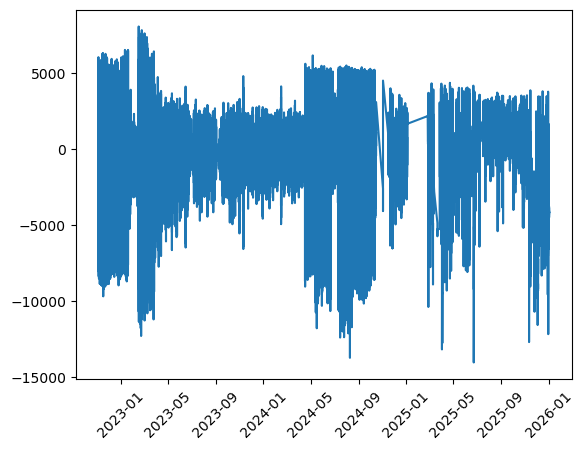

In [ ]:
# The next few windows plot the data for each room. The x-axis is the timestamp, and the y-axis is the sensible load.

plt.plot(df1121_sensible_load)
plt.xticks(rotation=45)
plt.show()

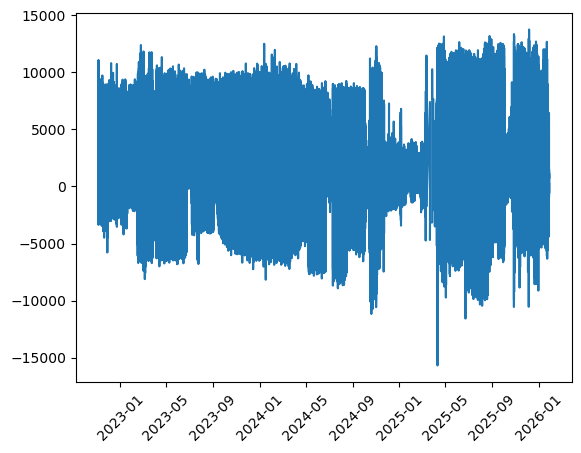

In [5]:
plt.plot(df1131_sensible_load)
plt.xticks(rotation=45)
plt.show()

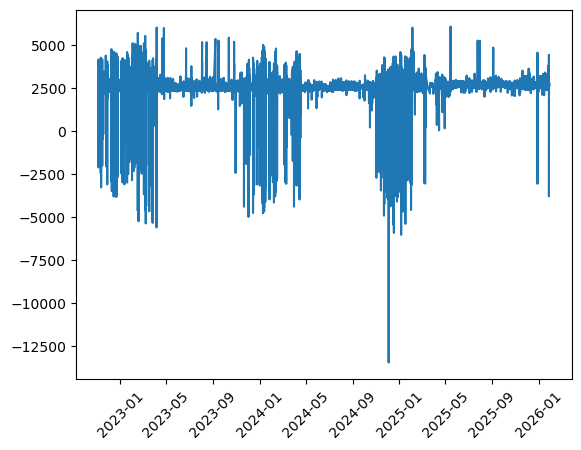

In [ ]:
#plt.plot(df1331_sensible_load)
#plt.xticks(rotation=45)
#plt.show()

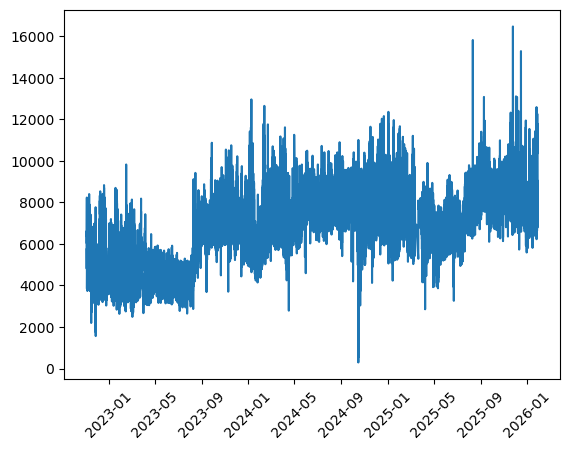

In [34]:
# 1331 is missing a lot of data, but should still be useful.

plt.plot(df1315_sensible_load)
plt.xticks(rotation=45)
plt.show()

In [6]:
# Makes a new dataframe that records previous sensible load values as features.

lags = [1, 2, 3, 4, 5, 6]

def create_lags(series, lags):
    df = series.to_frame(name="y").copy()
    for lag in lags:
        df[f"y_lag_{lag}"] = df["y"].shift(lag)
    return df

df_model = create_lags(df1121_sensible_load, lags)

df_model = df_model.dropna()

train_size = int(0.8 * len(df_model))

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]
df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6
ts,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292


In [7]:
# Adds time features to the model.

df_model["hour"] = df_model.index.hour
df_model["minute"] = df_model.index.minute
df_model["dayofweek"] = df_model.index.dayofweek

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek
ts,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4


In [8]:
# Create rolling statistics

windows = [12, 24, 48]

for w in windows:
        df_model[f"roll_mean_{w}"] = df_model["y"].shift(1).rolling(w).mean()
        df_model[f"roll_std_{w}"] = df_model["y"].shift(1).rolling(w).std()
        df_model[f"roll_min_{w}"] = df_model["y"].shift(1).rolling(w).min()
        df_model[f"roll_max_{w}"] = df_model["y"].shift(1).rolling(w).max()

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,roll_min_12,roll_max_12,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_48,roll_std_48,roll_min_48,roll_max_48
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_model.tail()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,roll_min_12,roll_max_12,roll_mean_24,roll_std_24,roll_min_24,roll_max_24,roll_mean_48,roll_std_48,roll_min_48,roll_max_48
ts,,,,,,,,,,,,,,,,,,,,,
2026-01-02 06:45:00+00:00,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,-4171.257296,-4167.063351,6,45,4,...,-4284.509494,-3991.017404,-4148.294895,167.605294,-4493.012444,-3784.283285,-4147.314380,145.198514,-4493.012444,-3784.283285
2026-01-02 07:00:00+00:00,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,-4171.257296,7,0,4,...,-4247.329800,-3991.017404,-4150.159353,167.280790,-4493.012444,-3784.283285,-4150.460923,143.400630,-4493.012444,-3784.283285
2026-01-02 07:15:00+00:00,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,7,15,4,...,-4247.329800,-3991.017404,-4157.587999,160.005590,-4493.012444,-3784.283285,-4145.761433,141.578083,-4493.012444,-3784.283285
2026-01-02 07:30:00+00:00,-4178.770575,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,7,30,4,...,-4247.329800,-3991.017404,-4172.125437,139.097761,-4493.012444,-3864.743090,-4147.131951,141.121022,-4493.012444,-3784.283285
2026-01-02 07:45:00+00:00,-4112.427466,-4178.770575,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,7,45,4,...,-4247.329800,-3991.017404,-4163.146583,130.845487,-4493.012444,-3864.743090,-4147.513594,141.182567,-4493.012444,-3784.283285


In [ ]:
# Adds information about Rooms 1131, 1331, and 1315. In this version, I excluded Room 1331.

for lag in lags:
    df_model[f"y1131_lag_{lag}"] = df1131_sensible_load.shift(lag)
    df_model[f"y1331_lag_{lag}"] = df1331_sensible_load.shift(lag)
    df_model[f"y1315_lag_{lag}"] = df1315_sensible_load.shift(lag)

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,roll_mean_48,roll_std_48,roll_min_48,roll_max_48,y1131_lag_1,y1131_lag_2,y1131_lag_3,y1131_lag_4,y1131_lag_5,y1131_lag_6
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4,...,NaN,NaN,NaN,NaN,-1453.926768,8331.633258,247.195908,-2089.064827,8390.239974,7315.44498
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4,...,NaN,NaN,NaN,NaN,2765.745876,-1453.926768,8331.633258,247.195908,-2089.064827,8390.239974
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4,...,NaN,NaN,NaN,NaN,8370.634368,2765.745876,-1453.926768,8331.633258,247.195908,-2089.064827
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4,...,NaN,NaN,NaN,NaN,6240.033258,8370.634368,2765.745876,-1453.926768,8331.633258,247.195908
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4,...,NaN,NaN,NaN,NaN,3919.301717,6240.033258,8370.634368,2765.745876,-1453.926768,8331.633258


In [ ]:
# Incorporates rolling statistics for the neighboring rooms.

for w in windows:
        df_model[f"1131roll_mean_{w}"] = df1131_sensible_load.shift(1).rolling(w).mean()
        df_model[f"1131roll_std_{w}"] = df1131_sensible_load.shift(1).rolling(w).std()
        df_model[f"1131roll_min_{w}"] = df1131_sensible_load.shift(1).rolling(w).min()
        df_model[f"1131roll_max_{w}"] = df1131_sensible_load.shift(1).rolling(w).max()
        df_model[f"1331roll_mean_{w}"] = df1331_sensible_load.shift(1).rolling(w).mean()
        df_model[f"1331roll_std_{w}"] = df1331_sensible_load.shift(1).rolling(w).std()
        df_model[f"1331roll_min_{w}"] = df1331_sensible_load.shift(1).rolling(w).min()
        df_model[f"1331roll_max_{w}"] = df1331_sensible_load.shift(1).rolling(w).max()
        df_model[f"1315roll_mean_{w}"] = df1315_sensible_load.shift(1).rolling(w).mean()
        df_model[f"1315roll_std_{w}"] = df1315_sensible_load.shift(1).rolling(w).std()
        df_model[f"1315roll_min_{w}"] = df1315_sensible_load.shift(1).rolling(w).min()
        df_model[f"1315roll_max_{w}"] = df1315_sensible_load.shift(1).rolling(w).max()

df_model.head()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,1131roll_min_12,1131roll_max_12,1131roll_mean_24,1131roll_std_24,1131roll_min_24,1131roll_max_24,1131roll_mean_48,1131roll_std_48,1131roll_min_48,1131roll_max_48
ts,,,,,,,,,,,,,,,,,,,,,
2022-11-04 01:45:00+00:00,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,3702.334110,1,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:00:00+00:00,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,-7940.642403,2,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:15:00+00:00,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,-8025.785816,2,15,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:30:00+00:00,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,-7842.391521,2,30,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-04 02:45:00+00:00,4030.246455,-1710.999024,-4738.247238,3335.675047,4187.765633,-5327.691205,4625.440292,2,45,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Last five entries of the model dataframe. Note that there are many NaN values because of the rolling statistics.

df_model.tail()

,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,hour,minute,dayofweek,...,1131roll_min_12,1131roll_max_12,1131roll_mean_24,1131roll_std_24,1131roll_min_24,1131roll_max_24,1131roll_mean_48,1131roll_std_48,1131roll_min_48,1131roll_max_48
ts,,,,,,,,,,,,,,,,,,,,,
2026-01-02 06:45:00+00:00,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,-4171.257296,-4167.063351,6,45,4,...,723.626606,1822.192532,1201.693460,287.561661,637.234434,1822.192532,1304.737466,296.987223,637.234434,1826.594852
2026-01-02 07:00:00+00:00,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,-4171.257296,7,0,4,...,723.626606,1822.192532,1213.995574,279.938420,637.234434,1822.192532,1291.411845,287.264355,637.234434,1822.192532
2026-01-02 07:15:00+00:00,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,-4147.481520,7,15,4,...,723.626606,1822.192532,1203.712036,265.970805,637.234434,1822.192532,1296.056907,287.850476,637.234434,1822.192532
2026-01-02 07:30:00+00:00,-4178.770575,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,-3991.017404,7,30,4,...,723.626606,1440.744389,1184.924390,262.772301,637.234434,1822.192532,1288.420467,290.465732,637.234434,1822.192532
2026-01-02 07:45:00+00:00,-4112.427466,-4178.770575,-4133.181796,-4089.432094,-4143.671911,-4227.799896,-4158.171796,7,45,4,...,723.626606,1489.659556,1201.663917,269.045035,637.234434,1822.192532,1285.518918,287.674080,637.234434,1822.192532


In [ ]:
df_model = df_model.dropna() # Drops missing rows

In [14]:
features = df_model.columns.drop("y")

X = df_model[features] # What we will use to predict
y = df_model["y"] # What we want to predict

split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

ts_test = df_model.iloc[split:]

In [ ]:
# Creates and fits the XGBoost model. Note that I used the same hyperparameters as in AAR1121v3.ipynb,
# which were found through hyperparameter tuning.

from xgboost import XGBRegressor

model = XGBRegressor(
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
pred = model.predict(X_test) # Makes predictions on the test set

In [17]:
results = df_model.iloc[split:].copy()
results["prediction"] = pred

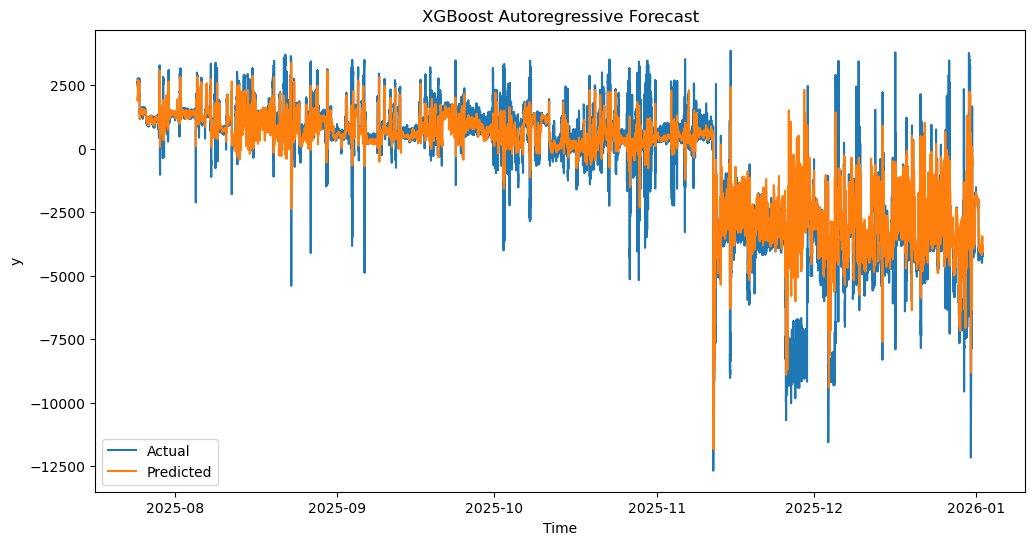

In [ ]:
# Plots predictions vs actual values.

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(results.index, results["y"], label="Actual")
plt.plot(results.index, results["prediction"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

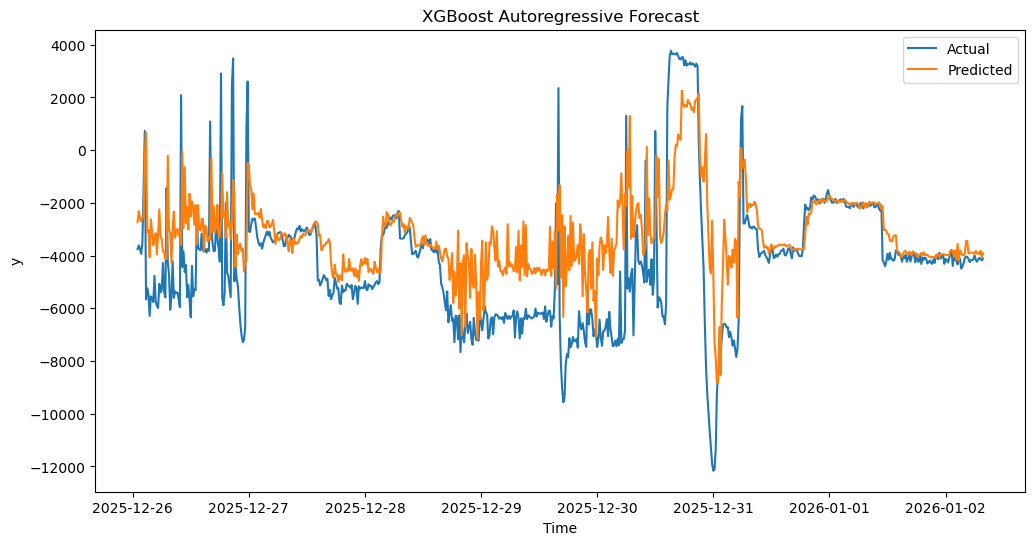

In [19]:
# Here is the output restricted to the final week of 2025.

plt.figure(figsize=(12,6))

plt.plot(results.index[-700:], results["y"][-700:], label="Actual")
plt.plot(results.index[-700:], results["prediction"][-700:], label="Predicted")

plt.xlabel("Time")
plt.ylabel("y")
plt.title("XGBoost Autoregressive Forecast")

plt.legend()
plt.show()

In [ ]:
# Records some evaluation metrics.
# The correlations actually decreased to 89.1%. So, the model is worse than the previous version.
# One problem is that when one of the neighboring rooms has missing data, the model ignores that timestamp for all rooms.
# So, the model is actually using less data than the previous version.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

corr = results["y"].corr(results["prediction"])
mae = mean_absolute_error(results["y"], results["prediction"])
rmse = np.sqrt(mean_squared_error(results["y"], results["prediction"]))
r2 = r2_score(results["y"], results["prediction"])

print("Correlation:", corr)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Correlation: 0.8907118042097877
MAE: 726.1471414466461
RMSE: 1361.1643762509993
R²: 0.759119760270557
